# Catalog Pipeline (production version)

Picks up from `ocr_testing.ipynb`. Qwen2-VL-2B won the OCR backend ablation (avg CLIP sim 0.796 vs PaddleOCR 0.720), so this notebook commits to it and builds out the rest of the system:

1. **Structured JSON OCR** — prompt Qwen2-VL to emit `{title, author, publisher}` per spine instead of raw text.
2. **Title resolution / disambiguation** — smarter Google Books query + re-rank using publication date and author overlap.
3. **Catalog data model** — one pandas DataFrame / JSON manifest per shelf, with confidence + review flags.
4. **Failure-mode handling** — `unreadable` / `low_confidence` / `ambiguous` buckets instead of silent drops.
5. **End-to-end evaluation** — system-level metric: `% of spines correctly matched to a Google Books record` on a held-out ground-truth set.
6. **Frontend** — minimal Gradio app: upload shelf photo → rendered catalog (thumbnails + titles).


## 0) Shared setup

Duplicating the imports + detector + Google Books + CLIP setup here (rather than `%run`-ing `ocr_testing.ipynb`) so this notebook is self-contained and reproducible.


In [5]:
import os, json, time, re
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

DATA_DIR = Path("data/LibVision-2")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

BOOK_CLASS_ID = 0
NUM_CLASSES = 2
DET_SCORE_THRESH = 0.5
CROP_PAD_FRAC = 0.05
OCR_MIN_SHORT_SIDE = 320

WEIGHTS_PATH = Path("models/fasterrcnn_book.pt")
CATALOG_DIR = Path("catalogs")
CATALOG_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [29]:
# --- Detector (same Faster R-CNN weights used in the baseline) ---
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models import ResNet18_Weights
from torchvision.transforms import ToTensor
from torchvision.ops import nms

def build_faster_rcnn():
    backbone = resnet_fpn_backbone(backbone_name="resnet18", weights=ResNet18_Weights.DEFAULT)
    return FasterRCNN(backbone, num_classes=NUM_CLASSES)

detector = build_faster_rcnn().to(device)
detector.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
detector.eval()
print(f"Loaded detector from {WEIGHTS_PATH}")

def _pad_box(x1, y1, x2, y2, W, H, frac=CROP_PAD_FRAC):
    bw, bh = x2 - x1, y2 - y1
    px, py = bw * frac, bh * frac
    return (max(0, int(x1 - px)), max(0, int(y1 - py)),
            min(W, int(x2 + px)), min(H, int(y2 + py)))

DET_NMS_IOU = 0.30  # post-NMS to get rid of duplicate boxes on the same spine

def detect_spines(pil_img: Image.Image, score_thresh: float = DET_SCORE_THRESH):
    W, H = pil_img.size
    img_t = ToTensor()(pil_img).to(device)
    with torch.no_grad():
        pred = detector([img_t])[0]
    boxes = pred["boxes"].detach().cpu()
    labels = pred["labels"].detach().cpu().numpy()
    scores = pred["scores"].detach().cpu()
 
    keep_mask = (labels == 1) & (scores.numpy() >= score_thresh)
    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    if len(boxes) == 0:
        return []
 
    keep = nms(boxes, scores, DET_NMS_IOU).numpy()
    boxes = boxes.numpy()
    scores = scores.numpy()
 
    spines = []
    for idx in keep:
        x1, y1, x2, y2 = boxes[idx]
        sc = scores[idx]
        px1, py1, px2, py2 = _pad_box(x1, y1, x2, y2, W, H)
        spines.append({
            "bbox": (float(x1), float(y1), float(x2), float(y2)),
            "score": float(sc),
            "crop": pil_img.crop((px1, py1, px2, py2)),
        })
    return spines

Loaded detector from models/fasterrcnn_book.pt


## 1) Qwen2-VL-2B with structured JSON output

Instead of free-form text, we prompt Qwen2-VL to return **strict JSON** per spine:

```json
{"title": "...", "author": "...", "publisher": "...", "readable": true, "confidence": "high|medium|low"}
```

Why: `title` and `author` become **separate Google Books query fields** (`intitle:` / `inauthor:`), which dramatically cuts candidate-pool noise vs. a single blob query. `readable` + `confidence` feed the failure-mode router in step 4.


In [17]:
_qwen2vl = None
QWEN2VL_MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"
# Book spines are small text. We cap image tokens aggressively: Qwen's vision
# attention is O(n^2) in token count, so halving pixels ~4x's throughput.
QWEN2VL_MIN_PIXELS = 128 * 28 * 28      # ~100K px  (was 256*28*28 = 200K)
QWEN2VL_MAX_PIXELS = 384 * 28 * 28      # ~300K px  (was 1280*28*28 = 1M)
QWEN2VL_MAX_NEW_TOKENS = 96             # JSON output is short (was 160)

QWEN2VL_JSON_PROMPT = (
    "This image shows a single book spine. Read the text and return a strict JSON object "
    "with exactly these keys and nothing else: "
    '{"title": string, "author": string, "publisher": string, "readable": bool, "confidence": "high"|"medium"|"low"}. '
    "Use an empty string for any field you cannot read. Set readable=false if the spine is too worn, "
    "blurry, or stylized to extract any text. Return ONLY the JSON, no prose, no code fences."
)

def _get_qwen2vl():
    global _qwen2vl
    if _qwen2vl is None:
        from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
        torch_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"
        proc = AutoProcessor.from_pretrained(
            QWEN2VL_MODEL_NAME,
            min_pixels=QWEN2VL_MIN_PIXELS,
            max_pixels=QWEN2VL_MAX_PIXELS,
        )
        mdl = Qwen2VLForConditionalGeneration.from_pretrained(
            QWEN2VL_MODEL_NAME, torch_dtype=torch_dtype, device_map={"": target},
        )
        mdl.eval()
        _qwen2vl = {"processor": proc, "model": mdl, "device": target, "dtype": torch_dtype}
    return _qwen2vl

# Aspect-ratio-aware preprocessing. Book spines are often very tall/narrow
# (e.g. 80x1400 px in the shelf photo). Upscaling such a crop blows up the
# long-axis token count and kills vision attention speed. Instead, downscale
# the LONG side if it exceeds a budget, preserving aspect ratio.
QWEN2VL_MAX_LONG_SIDE = 896   # px; keeps vision token count manageable

def _preprocess_crop(crop: Image.Image,
                     max_long_side: int = QWEN2VL_MAX_LONG_SIDE) -> Image.Image:
    w, h = crop.size
    long_side = max(w, h)
    if long_side > max_long_side:
        scale = max_long_side / long_side
        crop = crop.resize(
            (max(1, int(round(w * scale))), max(1, int(round(h * scale)))),
            Image.LANCZOS,
        )
    return ImageOps.autocontrast(crop, cutoff=2)

_JSON_RE = re.compile(r"\{.*\}", re.DOTALL)

def _parse_qwen_json(raw: str) -> Dict:
    """Best-effort JSON parse of the model output. Always returns a dict with the expected keys."""
    empty = {"title": "", "author": "", "publisher": "",
             "readable": False, "confidence": "low", "raw": raw}
    if not raw:
        return empty
    m = _JSON_RE.search(raw)
    if not m:
        return {**empty, "raw": raw}
    try:
        parsed = json.loads(m.group(0))
    except json.JSONDecodeError:
        return {**empty, "raw": raw}
    out = {
        "title": str(parsed.get("title", "")).strip(),
        "author": str(parsed.get("author", "")).strip(),
        "publisher": str(parsed.get("publisher", "")).strip(),
        "readable": bool(parsed.get("readable", True)),
        "confidence": str(parsed.get("confidence", "medium")).strip().lower(),
        "raw": raw,
    }
    if out["confidence"] not in {"high", "medium", "low"}:
        out["confidence"] = "medium"
    return out

def qwen2vl_read_spine(crop: Image.Image) -> Dict:
    bundle = _get_qwen2vl()
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device, mdl_dtype = bundle["device"], bundle["dtype"]

    pil = _preprocess_crop(crop if isinstance(crop, Image.Image) else Image.fromarray(crop))
    if pil.mode != "RGB":
        pil = pil.convert("RGB")

    messages = [{"role": "user", "content": [
        {"type": "image", "image": pil},
        {"type": "text",  "text":  QWEN2VL_JSON_PROMPT},
    ]}]
    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    try:
        from qwen_vl_utils import process_vision_info
        image_inputs, video_inputs = process_vision_info(messages)
    except Exception:
        image_inputs, video_inputs = [pil], None

    inputs = proc(text=[chat_text], images=image_inputs, videos=video_inputs,
                  padding=True, return_tensors="pt")
    moved = {}
    for k, v in inputs.items():
        if isinstance(v, torch.Tensor):
            v = v.to(mdl_device)
            if v.is_floating_point():
                v = v.to(mdl_dtype)
        moved[k] = v
    with torch.no_grad():
        gen_ids = mdl.generate(**moved, max_new_tokens=QWEN2VL_MAX_NEW_TOKENS, do_sample=False)
    trimmed = [out[len(inp):] for inp, out in zip(moved["input_ids"], gen_ids)]
    raw = proc.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    return _parse_qwen_json(raw)

In [18]:
import subprocess
bundle = _get_qwen2vl()
mdl = bundle["model"]

# 1. Where are the weights actually?
param_devs = {str(p.device) for p in mdl.parameters()}
print("Model parameter devices:", param_devs)
print("Model dtype sample:", next(mdl.parameters()).dtype)

# 2. GPU memory sanity check
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Allocated:   {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"Reserved:    {torch.cuda.memory_reserved()/1e9:.2f} GB")
    try:
        out = subprocess.check_output(["nvidia-smi", "--query-gpu=utilization.gpu,memory.used,memory.total",
                                       "--format=csv,noheader"]).decode().strip()
        print(f"nvidia-smi:  {out}")
    except Exception as e:
        print(f"nvidia-smi not available: {e}")

# 3. Throughput test on one spine (so you know what baseline to expect)
from PIL import Image as _Im
import time as _time
test_img = _Im.new("RGB", (320, 640), color=(128, 128, 128))
_ = qwen2vl_read_spine(test_img)  # warmup
t0 = _time.time()
for _ in range(3):
    _ = qwen2vl_read_spine(test_img)
print(f"\nAvg time/spine on blank 320x640: {(_time.time()-t0)/3:.2f}s")

pil = Image.open("data/my-books/shelf_1.jpeg").convert("RGB")
spines = detect_spines(pil)
crop = spines[0]["crop"]
print(f"Raw crop size: {crop.size}")
_ = qwen2vl_read_spine(crop)  # warmup
t0 = _time.time()
for _ in range(3):
    _ = qwen2vl_read_spine(crop)
print(f"Avg on real spine: {(_time.time()-t0)/3:.2f}s")

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.80s/it]
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only 

Model parameter devices: {'cuda:0'}
Model dtype sample: torch.bfloat16
CUDA device: NVIDIA GeForce RTX 4070 Ti
Allocated:   5.17 GB
Reserved:    10.24 GB
nvidia-smi:  15 %, 10728 MiB, 12282 MiB

Avg time/spine on blank 320x640: 0.79s
Raw crop size: (401, 3127)
Avg on real spine: 1.06s


## 2) Title resolution / disambiguation

Because Qwen2-VL gives us structured fields, we build a **smarter Google Books query**:

- `intitle:"<title>" inauthor:"<author>"` when both are present (very high precision).
- `intitle:"<title>"` when only the title is present.
- Fall back to the raw blob if both are empty (old behavior).

We then **re-rank** candidates by: (CLIP text similarity) + (author overlap bonus) + (publication-date recency bonus, small).


In [19]:
import requests

GB_CACHE_PATH = Path("cache/google_books.json")
GB_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
_gb_cache: Dict[str, List[dict]] = (
    json.loads(GB_CACHE_PATH.read_text()) if GB_CACHE_PATH.exists() else {}
)
GB_API_KEY = os.environ.get("GOOGLE_BOOKS_API_KEY", "").strip()
GB_TOPK = 20
GB_MIN_INTERVAL_S = 1.1          # min gap between calls (unauthenticated throttle is strict)
GB_MAX_RETRIES = 4
GB_BACKOFF_BASE_S = 2.0
_gb_last_call_ts = 0.0

def _gb_throttle():
    global _gb_last_call_ts
    wait = GB_MIN_INTERVAL_S - (time.time() - _gb_last_call_ts)
    if wait > 0: time.sleep(wait)
    _gb_last_call_ts = time.time()

def _save_gb_cache():
    GB_CACHE_PATH.write_text(json.dumps(_gb_cache))

def build_gb_query(ocr: Dict) -> str:
    title = re.sub(r'[\"\\\\]', ' ', ocr.get("title", "") or "").strip()
    author = re.sub(r'[\"\\\\]', ' ', ocr.get("author", "") or "").strip()
    # Qwen sometimes literally emits "Unknown" / "N/A" — treat as empty.
    if author.lower() in {"unknown", "n/a", "none", "anonymous"}:
        author = ""
    if title and author:
        return f'intitle:"{title}" inauthor:"{author}"'
    if title:
        return f'intitle:"{title}"'
    if author:
        return f'inauthor:"{author}"'
    return (ocr.get("raw") or "").strip()[:80]

def _gb_request_once(params: dict) -> Tuple[Optional[dict], Optional[int], Optional[str]]:
    """Return (json_or_None, status_code_or_None, err_name_or_None)."""
    try:
        r = requests.get("https://www.googleapis.com/books/v1/volumes",
                         params=params, timeout=10)
    except requests.RequestException as e:
        return None, None, type(e).__name__
    if r.status_code == 200:
        try:
            return r.json(), 200, None
        except ValueError:
            return None, 200, "BadJSON"
    return None, r.status_code, None

def query_google_books(query: str, top_k: int = GB_TOPK,
                       verbose: bool = False) -> List[dict]:
    q = (query or "").strip()
    if len(q) < 3:
        return []
    key = f"{q}|{top_k}"
    if key in _gb_cache:
        return _gb_cache[key]

    params = {"q": q, "maxResults": min(40, top_k), "printType": "books"}
    if GB_API_KEY:
        params["key"] = GB_API_KEY

    data = None
    for attempt in range(GB_MAX_RETRIES):
        _gb_throttle()
        data, status, err = _gb_request_once(params)
        if data is not None:
            break
        # Decide whether to retry
        retryable = (err is not None) or (status == 429) or (status is not None and 500 <= status < 600)
        if verbose or attempt == GB_MAX_RETRIES - 1:
            print(f"GB {q!r} attempt {attempt+1}/{GB_MAX_RETRIES}: "
                  f"status={status} err={err}")
        if not retryable:
            break   # 4xx other than 429 -> don't retry (usually malformed query)
        sleep_s = GB_BACKOFF_BASE_S * (2 ** attempt)
        time.sleep(sleep_s)

    if data is None:
        # Do NOT cache failures — leaves room to retry later in a new run.
        return []

    out = []
    for item in data.get("items", [])[:top_k]:
        vi = item.get("volumeInfo", {})
        ids = {x.get("type"): x.get("identifier") for x in vi.get("industryIdentifiers", []) or []}
        out.append({
            "volumeId": item.get("id", ""),
            "title": vi.get("title", ""),
            "subtitle": vi.get("subtitle", ""),
            "authors": vi.get("authors", []),
            "publisher": vi.get("publisher", ""),
            "publishedDate": vi.get("publishedDate", ""),
            "categories": vi.get("categories", []),
            "isbn": ids.get("ISBN_13") or ids.get("ISBN_10") or "",
            "thumbnail": vi.get("imageLinks", {}).get("thumbnail", ""),
        })
    _gb_cache[key] = out
    _save_gb_cache()
    return out

In [20]:
# CLIP text encoder for similarity scoring
import open_clip
CLIP_MODEL_NAME = "ViT-B-32"
CLIP_PRETRAINED = "laion2b_s34b_b79k"
_clip_model, _, _ = open_clip.create_model_and_transforms(CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED)
_clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
_clip_model = _clip_model.to(device).eval()

@torch.no_grad()
def clip_text_embed(texts: List[str]) -> torch.Tensor:
    if not texts:
        return torch.zeros((0, 512), device=device)
    tokens = _clip_tokenizer(texts).to(device)
    emb = _clip_model.encode_text(tokens)
    return emb / emb.norm(dim=-1, keepdim=True).clamp(min=1e-8)

def _author_overlap(ocr_author: str, cand_authors: List[str]) -> float:
    if not ocr_author or not cand_authors:
        return 0.0
    a = set(re.findall(r"[a-z]+", ocr_author.lower()))
    b = set(re.findall(r"[a-z]+", " ".join(cand_authors).lower()))
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def rerank_candidates(ocr: Dict, candidates: List[dict],
                      spine_crop: Optional[Image.Image] = None,
                      w_author: float = 0.15, w_date: float = 0.02,
                      w_image: float = 0.35) -> List[Tuple[dict, float, Dict]]:
    """Score = text_sim + w_image*image_sim + w_author*overlap + w_date*recency."""
    if not candidates:
        return []
    query_text = f"{ocr.get('title','')} {ocr.get('author','')}".strip() or ocr.get("raw", "")
    sp = clip_text_embed([query_text])
    cand_texts = [f"{c['title']} {', '.join(c.get('authors', []))}".strip() for c in candidates]
    cd = clip_text_embed(cand_texts)
    sims = (sp @ cd.T).detach().cpu().numpy().flatten()

    img_sims = (clip_image_sims(spine_crop, candidates)
                if spine_crop is not None else np.zeros(len(candidates), dtype=np.float32))

    scored = []
    for c, sim_t, sim_i in zip(candidates, sims, img_sims):
        ao = _author_overlap(ocr.get("author", ""), c.get("authors", []))
        year = 0
        m = re.search(r"(\d{4})", c.get("publishedDate", "") or "")
        if m:
            year = int(m.group(1))
        recency = min(max((year - 1900) / 125.0, 0.0), 1.0) if year else 0.0
        score = float(sim_t) + w_image * float(sim_i) + w_author * ao + w_date * recency
        scored.append((c, score, {
            "clip_sim": float(sim_t), "image_sim": float(sim_i),
            "author_overlap": ao, "year": year,
        }))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored

In [21]:
from io import BytesIO

# Get CLIP's image preprocessing transform (model was loaded in the CLIP cell).
_, _, _clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED
)

THUMB_CACHE_DIR = Path("cache/thumbnails")
THUMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _download_thumbnail(url: str) -> Optional[Image.Image]:
    if not url:
        return None
    safe = url.replace("://", "_").replace("/", "_").replace("?", "_")[:180]
    cache_path = THUMB_CACHE_DIR / (safe + ".jpg")
    if cache_path.exists():
        try:
            return Image.open(cache_path).convert("RGB")
        except Exception:
            cache_path.unlink(missing_ok=True)
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(cache_path, format="JPEG")
        return img
    except Exception:
        return None

@torch.no_grad()
def clip_image_embed(images: List[Image.Image]) -> torch.Tensor:
    if not images:
        return torch.zeros((0, 512), device=device)
    batch = torch.stack([_clip_preprocess(im) for im in images]).to(device)
    emb = _clip_model.encode_image(batch)
    return emb / emb.norm(dim=-1, keepdim=True).clamp(min=1e-8)

def clip_image_sims(spine_crop: Image.Image, candidates: List[dict]) -> np.ndarray:
    """Cosine sim between one spine crop and each candidate's cover thumbnail.
    Candidates without a usable thumbnail get sim=0 (fusion falls back to text)."""
    if not candidates:
        return np.zeros(0, dtype=np.float32)
    thumbs = [_download_thumbnail(c.get("thumbnail", "")) for c in candidates]
    have_idx = [j for j, im in enumerate(thumbs) if im is not None]
    sims = np.zeros(len(candidates), dtype=np.float32)
    if not have_idx:
        return sims
    sp = clip_image_embed([spine_crop])
    cd = clip_image_embed([thumbs[j] for j in have_idx])
    row = (sp @ cd.T).detach().cpu().numpy().flatten()
    for col, j in enumerate(have_idx):
        sims[j] = row[col]
    return sims

## 3) Catalog data model

Per spine, we store a flat record. A shelf = list of records; a catalog = pandas DataFrame saved as both JSON manifest and CSV. Review flags (`unreadable`, `low_confidence`, `ambiguous`, `ok`) come from  step 4.


In [22]:
import pandas as pd
import hashlib

CATALOG_COLUMNS = [
    "shelf_id", "spine_idx", "bbox", "det_score",
    "ocr_title", "ocr_author", "ocr_publisher",
    "ocr_readable", "ocr_confidence",
    "match_title", "match_authors", "match_publisher", "match_publishedDate",
    "match_categories", "match_isbn", "match_volumeId", "match_thumbnail",
    "match_score", "clip_sim", "author_overlap",
    "review_flag",
]

def shelf_id_for(path: Path) -> str:
    return hashlib.md5(str(Path(path).resolve()).encode()).hexdigest()[:10]

def empty_record(shelf_id: str, idx: int, spine: Dict) -> Dict:
    return {
        "shelf_id": shelf_id, "spine_idx": idx,
        "bbox": spine["bbox"], "det_score": spine["score"],
        "ocr_title": "", "ocr_author": "", "ocr_publisher": "",
        "ocr_readable": False, "ocr_confidence": "low",
        "match_title": "", "match_authors": [], "match_publisher": "",
        "match_publishedDate": "", "match_categories": [], "match_isbn": "",
        "match_volumeId": "", "match_thumbnail": "",
        "match_score": 0.0, "clip_sim": 0.0, "author_overlap": 0.0,
        "review_flag": "unreadable",
    }

## 4) Failure-mode handling

Graceful router — no silent drops. Every spine lands in one of four buckets:

- `unreadable` — OCR says `readable=false`, OR `title` and `author` both empty.
- `low_confidence` — OCR readable but `confidence=low`, OR top match `clip_sim < LOW_SIM`.
- `ambiguous` — top two candidates within `AMBIG_DELTA` score of each other (pick top but flag).
- `ok` — everything else.

Only `ok` (and optionally `ambiguous`) rows are shown as confident catalog entries; the others are surfaced for review.


In [23]:
MATCH_SIM_THRESHOLD = 0.25   # below this -> low_confidence
AMBIG_DELTA = 0.02           # top-1 vs top-2 score gap under this -> ambiguous
MIN_TITLE_CHARS = 3          # shorter than this -> unreadable


def _is_text_readable(ocr: Dict) -> bool:
    """Ignore Qwen's self-reported `readable` flag (it's too conservative).
    Call it readable if there's any non-trivial title or author text."""
    title = (ocr.get("title") or "").strip()
    author = (ocr.get("author") or "").strip()
    if author.lower() in {"unknown", "n/a", "none", "anonymous", ""}:
        author = ""
    if len(title) >= MIN_TITLE_CHARS:
        return True
    if len(author) >= MIN_TITLE_CHARS:
        return True
    return False


def classify_spine(ocr: Dict, ranked: List[Tuple[dict, float, Dict]]) -> Tuple[str, Optional[Tuple[dict, float, Dict]]]:
    """Return (review_flag, top_candidate_or_None)."""
    if not _is_text_readable(ocr):
        return "unreadable", None
    if not ranked:
        # OCR'd text but GB found nothing (too-strict query, or truly obscure book)
        return "low_confidence", None
    top = ranked[0]
    _, top_score, meta = top
    if meta["clip_sim"] < MATCH_SIM_THRESHOLD or ocr.get("confidence") == "low":
        return "low_confidence", top
    if len(ranked) > 1 and (top_score - ranked[1][1]) < AMBIG_DELTA:
        return "ambiguous", top
    return "ok", top


## 5) End-to-end pipeline

Glues steps 1–4 together: one shelf image in, one DataFrame out (+ JSON manifest on disk).


In [24]:
def build_gb_query_chain(ocr: Dict) -> List[str]:
    """Progressive fallback: try the most precise query first, then loosen.
    First query that returns results wins. This recovers from Qwen
    hallucinating the wrong author next to a correct title."""
    title = re.sub(r'[\"\\\\]', ' ', ocr.get("title", "") or "").strip()
    author = re.sub(r'[\"\\\\]', ' ', ocr.get("author", "") or "").strip()
    if author.lower() in {"unknown", "n/a", "none", "anonymous"}:
        author = ""
    chain: List[str] = []
    if title and author:
        chain.append(f'intitle:"{title}" inauthor:"{author}"')
    if title:
        chain.append(f'intitle:"{title}"')
    if title and author:
        chain.append(f"{title} {author}")
    if author and not title:
        chain.append(f'inauthor:"{author}"')
    if not chain:
        blob = (ocr.get("raw") or "").strip()[:80]
        if blob:
            chain.append(blob)
    seen, out = set(), []
    for q in chain:
        if q not in seen:
            seen.add(q)
            out.append(q)
    return out


def catalog_shelf(image_path: Path, save: bool = True,
                  verbose: bool = False, progress: bool = True) -> pd.DataFrame:
    """
    Args:
        verbose:  print full per-spine detail (ocr text + query + hit count).
        progress: print lightweight spine counter (i/N + truncated title).
    """
    image_path = Path(image_path)
    shelf_id = shelf_id_for(image_path)
    t_shelf = time.time()
    with Image.open(image_path) as im:
        pil = im.convert("RGB")
    spines = detect_spines(pil)
    if progress:
        print(f"  [{image_path.name}] detected {len(spines)} spines", flush=True)
    rows: List[Dict] = []
    for i, s in enumerate(spines):
        t_spine = time.time()
        rec = empty_record(shelf_id, i, s)
        ocr = qwen2vl_read_spine(s["crop"])
        rec.update({
            "ocr_title": ocr["title"], "ocr_author": ocr["author"],
            "ocr_publisher": ocr["publisher"],
            "ocr_readable": ocr["readable"], "ocr_confidence": ocr["confidence"],
        })

        candidates: List[dict] = []
        used_query = ""
        for q in build_gb_query_chain(ocr):
            candidates = query_google_books(q)
            if candidates:
                used_query = q
                break

        ranked = rerank_candidates(ocr, candidates, spine_crop=s["crop"])
        flag, top = classify_spine(ocr, ranked)
        rec["review_flag"] = flag
        if top is not None:
            c, score, meta = top
            rec.update({
                "match_title": c["title"], "match_authors": c["authors"],
                "match_publisher": c["publisher"], "match_publishedDate": c["publishedDate"],
                "match_categories": c.get("categories", []), "match_isbn": c.get("isbn", ""),
                "match_volumeId": c["volumeId"], "match_thumbnail": c["thumbnail"],
                "match_score": score, "clip_sim": meta["clip_sim"],
                "author_overlap": meta["author_overlap"],
            })
        rows.append(rec)

        if verbose:
            print(f"    spine {i+1:>2d}/{len(spines)}: "
                  f"ocr={ocr['title']!r}/{ocr['author']!r} -> "
                  f"query={used_query!r} ({len(candidates)} hits) "
                  f"-> {flag}  [{time.time()-t_spine:.1f}s]", flush=True)
        elif progress:
            title_preview = (ocr["title"] or "(no title)")[:40]
            print(f"    spine {i+1:>2d}/{len(spines)}: {title_preview:<42s} "
                  f"-> {flag:<14s} [{time.time()-t_spine:.1f}s]", flush=True)

    df = pd.DataFrame(rows, columns=CATALOG_COLUMNS)
    if progress or verbose:
        dt = time.time() - t_shelf
        flag_counts = df["review_flag"].value_counts().to_dict()
        print(f"  [{image_path.name}] done in {dt:.1f}s  flags={flag_counts}", flush=True)
    if save:
        base = CATALOG_DIR / f"shelf_{shelf_id}"
        df.to_csv(base.with_suffix(".csv"), index=False)
        df.to_json(base.with_suffix(".json"), orient="records", indent=2)
        print(f"Saved catalog -> {base}.csv / .json  ({len(df)} spines)")
    return df

In [12]:
# Smoke test on one validation image
valid_images = sorted([p for p in (DATA_DIR / "valid" / "images").iterdir()
                       if p.suffix.lower() in IMAGE_EXTS])
print(f"{len(valid_images)} valid images")

df = catalog_shelf(valid_images[0])
print("\nFlag distribution:")
print(df["review_flag"].value_counts())
df[["spine_idx", "ocr_title", "ocr_author", "match_title", "clip_sim", "review_flag"]]

96 valid images


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

GB error for 'intitle:"The Seven Usual Sins"': HTTPError
GB error for 'intitle:"The Wicked King"': HTTPError
GB error for 'intitle:"The Atlas Paradox"': HTTPError
GB error for 'intitle:"By a Thread of Lucy Score"': HTTPError
GB error for 'By a Thread of Lucy Score Lucy Score': HTTPError
GB error for 'intitle:"Holidays and a Wedding"': HTTPError
GB error for 'intitle:"They Both Die at the End"': HTTPError
Saved catalog -> catalogs/shelf_84450a15f6.csv / .json  (57 spines)

Flag distribution:
review_flag
ambiguous         31
ok                12
unreadable        12
low_confidence     2
Name: count, dtype: int64


,spine_idx,ocr_title,ocr_author,match_title,clip_sim,review_flag
0,0,The Seven Usual Sins,Walter M. Newton,Christian Companion,0.599868,ambiguous
1,1,The Queen of Nothing,Katherineкин,The Queen of Nothing,0.802477,ok
2,2,The Cruel Prince,Holly O. McEveety,The Cruel Prince,0.892782,ambiguous
3,3,She Gets the Girl,Unknown,She Gets the Girl,0.749462,ambiguous
4,4,Bloodmarked,J. D. Robb,Bloodmarked,0.809359,ok
5,5,PAINTER,PAINTER,"The Painter's and Varnisher's Pocket Manual, Etc",0.703447,ambiguous
6,6,House of Sorrow,Erin S. Craig,House of Sorrow,0.814878,ok
7,7,Anatomy,Anna Schwartz,Human Anatomy,0.746577,ambiguous
8,8,,,,0.000000,unreadable
9,9,"Girl, Serpent, Thorn",Sara Shepard,"Girl, Serpent, Thorn",0.776061,ambiguous


## Test on my bookshelf by matching titles

dedupe

In [33]:
# Ablation A: dedupe only (no post-NMS, no CLIP image-sim rerank)
# Forces w_image=0 in the reranker and sets DET_NMS_IOU very high (0.99)
# so the post-NMS pass is effectively disabled — only Faster R-CNN's
# internal NMS @ 0.5 remains. Dedup of identical predicted titles is
# applied inside `evaluate` (always on).

ABLATION_RESULTS = globals().get("ABLATION_RESULTS", {})

_ORIG_RERANK = rerank_candidates
_ORIG_NMS_IOU = DET_NMS_IOU

def _rerank_no_image(*args, **kwargs):
    kwargs["w_image"] = 0.0
    return _ORIG_RERANK(*args, **kwargs)

rerank_candidates = _rerank_no_image
DET_NMS_IOU = 0.99  # effectively disable post-NMS

print(f"\n=== Ablation A: dedupe only (DET_NMS_IOU={DET_NMS_IOU}, w_image=0.0) ===")
try:
    res_dedup_only = evaluate(eval_imgs, gt_titles, verbose=True, progress=True)
    ABLATION_RESULTS["dedup_only"] = {
        "recall": res_dedup_only["recall"],
        "precision": res_dedup_only["precision"],
        "f1": res_dedup_only["f1"],
        "n_pred": res_dedup_only["n_pred"],
        "n_ok": res_dedup_only["n_ok"],
        "tp": res_dedup_only["tp"],
        "total_sec": res_dedup_only["total_sec"],
    }
finally:
    rerank_candidates = _ORIG_RERANK
    DET_NMS_IOU = _ORIG_NMS_IOU

print(f"\n[A] Recall={ABLATION_RESULTS['dedup_only']['recall']:.3f}  "
      f"Precision={ABLATION_RESULTS['dedup_only']['precision']:.3f}  "
      f"F1={ABLATION_RESULTS['dedup_only']['f1']:.3f}  "
      f"({ABLATION_RESULTS['dedup_only']['total_sec']/60:.1f} min)")


=== Ablation A: dedupe only (DET_NMS_IOU=0.99, w_image=0.0) ===

[shelf 1/10] shelf_1.jpeg  (elapsed 0.0m, ETA ?)
  [shelf_1.jpeg] detected 16 spines


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/16: People We Meet on Vacation                 -> ambiguous      [1.1s]
    spine  2/16: The Mary Shelley Club                      -> ok             [1.0s]
    spine  3/16: Crown of Midnight                          -> ambiguous      [1.0s]
    spine  4/16: Outlander                                  -> ok             [1.0s]
    spine  5/16: Throne of Glass                            -> ambiguous      [0.9s]
    spine  6/16: Throne of Glass                            -> ambiguous      [1.0s]
    spine  7/16: The Great Alone                            -> ambiguous      [1.0s]
    spine  8/16: Strength of the Few                        -> ambiguous      [0.9s]
    spine  9/16: Tower of Dawn                              -> ambiguous      [1.0s]
    spine 10/16: (no title)                                 -> unreadable     [0.7s]
    spine 11/16: (no title)                                 -> unreadable     [0.7s]
    spine 12/16: (no title)                                 -> un

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/17: The Opposite of Loneliness                 -> ok             [1.0s]
    spine  2/17: The Dead Romantics                         -> ambiguous      [1.0s]
    spine  3/17: FEEL THE BERN                              -> ok             [0.9s]
    spine  4/17: Tales of Two Americas: Stories of Inequa   -> ok             [3.0s]
    spine  5/17: The Design of Everyday Things              -> ok             [1.0s]
    spine  6/17: Talking to Strangers                       -> ambiguous      [1.0s]
    spine  7/17: So you want to talk about race             -> ok             [1.1s]
    spine  8/17: White Teeth                                -> ambiguous      [1.0s]
    spine  9/17: Bluebird                                   -> ok             [0.8s]
    spine 10/17: The Dead Romantics                         -> ambiguous      [1.0s]
    spine 11/17: (no title)                                 -> unreadable     [0.7s]
    spine 12/17: (no title)                                 -> un

...

    spine  1/11: Kingdom of Ash                             -> ambiguous      [1.1s]
    spine  2/11: Thursday Murder Club                       -> ambiguous      [0.9s]
    spine  3/11: One Last Stop                              -> ambiguous      [1.1s]
    spine  4/11: Empire of Storms                           -> ambiguous      [1.2s]
    spine  5/11: Circe                                      -> ambiguous      [1.0s]
    spine  6/11: Circe                                      -> ambiguous      [1.0s]
    spine  7/11: One Last Stop                              -> ambiguous      [1.1s]
    spine  8/11: Empire of Storms                           -> ambiguous      [3.0s]
    spine  9/11: The Thursday Murder Club                   -> ambiguous      [1.1s]
    spine 10/11: (no title)                                 -> unreadable     [0.7s]
    spine 11/11: The Thursday Murder Club                   -> ambiguous      [1.0s]
  [shelf_7.jpeg] done in 13.5s  flags={'ambiguous': 10, 'unreadab

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/13: Evicted                                    -> ambiguous      [0.9s]
    spine  2/13: the little liar                            -> ambiguous      [0.9s]
    spine  3/13: I'm Still Here                             -> ok             [1.0s]
    spine  4/13: Tell Me Three Things                       -> ambiguous      [1.0s]
    spine  5/13: WHY I'M NO LONGER TALKING TO WHITE PEOPL   -> ok             [1.4s]
    spine  6/13: Heaven & Earth                             -> ambiguous      [1.0s]
    spine  7/13: Why Are All the Black Kids Sitting Toget   -> ambiguous      [1.2s]
    spine  8/13: The Lost Causes of Bleak Creek             -> ambiguous      [1.2s]
    spine  9/13: looking for alaska                         -> ambiguous      [1.0s]
    spine 10/13: (no title)                                 -> unreadable     [0.7s]
    spine 11/13: Heaven & Earth Grocery Store               -> ambiguous      [1.1s]
    spine 12/13: (no title)                                 -> un

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/14: Sally Rooney: Intermezzo                   -> ok             [1.1s]
    spine  2/14: Exit Interview Kristi Coulter              -> ok             [1.0s]
    spine  3/14: How to Say Babylon                         -> ok             [1.0s]
    spine  4/14: OTHER PEOPLE'S CLOTHES                     -> ok             [0.9s]
    spine  5/14: (no title)                                 -> unreadable     [0.7s]
    spine  6/14: Forever                                    -> ambiguous      [1.0s]
    spine  7/14: Red, White & Royal Blue                    -> ambiguous      [1.1s]
    spine  8/14: Someone Else's Shoes                       -> ambiguous      [1.0s]
    spine  9/14: How to Say Babylon                         -> ok             [1.0s]
    spine 10/14: The Summer of Abby Jimenez                 -> ok             [1.8s]
    spine 11/14: How to Say Babylon                         -> ok             [1.1s]
    spine 12/14: Kristi Coulter                             -> am

dedupe + post-NMS @ 0.30 

In [34]:
# Ablation B: dedupe + post-NMS @ 0.30  (still no CLIP image-sim rerank)
# Same as Ablation A but enables the post-NMS pass at IoU = 0.30.

ABLATION_RESULTS = globals().get("ABLATION_RESULTS", {})

_ORIG_RERANK = rerank_candidates
_ORIG_NMS_IOU = DET_NMS_IOU

def _rerank_no_image(*args, **kwargs):
    kwargs["w_image"] = 0.0
    return _ORIG_RERANK(*args, **kwargs)

rerank_candidates = _rerank_no_image
DET_NMS_IOU = 0.30

print(f"\n=== Ablation B: dedupe + post-NMS @ 0.30 (w_image=0.0) ===")
try:
    res_dedup_nms = evaluate(eval_imgs, gt_titles, verbose=True, progress=True)
    ABLATION_RESULTS["dedup_plus_nms"] = {
        "recall": res_dedup_nms["recall"],
        "precision": res_dedup_nms["precision"],
        "f1": res_dedup_nms["f1"],
        "n_pred": res_dedup_nms["n_pred"],
        "n_ok": res_dedup_nms["n_ok"],
        "tp": res_dedup_nms["tp"],
        "total_sec": res_dedup_nms["total_sec"],
    }
finally:
    rerank_candidates = _ORIG_RERANK
    DET_NMS_IOU = _ORIG_NMS_IOU

print(f"\n[B] Recall={ABLATION_RESULTS['dedup_plus_nms']['recall']:.3f}  "
      f"Precision={ABLATION_RESULTS['dedup_plus_nms']['precision']:.3f}  "
      f"F1={ABLATION_RESULTS['dedup_plus_nms']['f1']:.3f}  "
      f"({ABLATION_RESULTS['dedup_plus_nms']['total_sec']/60:.1f} min)")

# Comparison table — assumes ablation A and full pipeline (cell b006339e) have
# already been run. The full-pipeline result is reconstructed from the printed
# numbers; if you re-run cell b006339e and store its `results` dict into
# ABLATION_RESULTS["full"], this will pick it up automatically.
ABLATION_RESULTS.setdefault("full", {
    "recall": 0.927, "precision": 0.874, "f1": 0.899,
    "n_pred": 87, "n_ok": 49, "tp": 76, "total_sec": 1.9 * 60,
})

print("\n=== Ablation summary ===")
print(f"{'config':<40s} {'recall':>8s} {'precision':>10s} {'f1':>7s} {'n_pred':>7s} {'n_ok':>5s} {'tp':>4s} {'min':>6s}")
order = [("dedup_only",      "dedupe only"),
         ("dedup_plus_nms",  "dedupe + post-NMS @ 0.30"),
         ("full",            "dedupe + post-NMS + CLIP image rerank")]
for key, label in order:
    if key not in ABLATION_RESULTS:
        continue
    r = ABLATION_RESULTS[key]
    print(f"{label:<40s} {r['recall']:>8.3f} {r['precision']:>10.3f} "
          f"{r['f1']:>7.3f} {r['n_pred']:>7d} {r['n_ok']:>5d} {r['tp']:>4d} "
          f"{r['total_sec']/60:>6.1f}")


=== Ablation B: dedupe + post-NMS @ 0.30 (w_image=0.0) ===

[shelf 1/10] shelf_1.jpeg  (elapsed 0.0m, ETA ?)
  [shelf_1.jpeg] detected 13 spines


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/13: People We Meet on Vacation                 -> ambiguous      [1.1s]
    spine  2/13: The Mary Shelley Club                      -> ok             [1.0s]
    spine  3/13: Crown of Midnight                          -> ambiguous      [1.0s]
    spine  4/13: Outlander                                  -> ok             [1.0s]
    spine  5/13: Throne of Glass                            -> ambiguous      [0.9s]
    spine  6/13: Throne of Glass                            -> ambiguous      [1.0s]
    spine  7/13: The Great Alone                            -> ambiguous      [1.0s]
    spine  8/13: Strength of the Few                        -> ambiguous      [0.9s]
    spine  9/13: Tower of Dawn                              -> ambiguous      [1.1s]
    spine 10/13: (no title)                                 -> unreadable     [0.7s]
    spine 11/13: (no title)                                 -> unreadable     [0.8s]
    spine 12/13: (no title)                                 -> un

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/11: The Opposite of Loneliness                 -> ok             [1.1s]
    spine  2/11: The Dead Romantics                         -> ambiguous      [1.1s]
    spine  3/11: FEEL THE BERN                              -> ok             [0.9s]
    spine  4/11: Tales of Two Americas: Stories of Inequa   -> ok             [1.2s]
    spine  5/11: The Design of Everyday Things              -> ok             [2.8s]
    spine  6/11: Talking to Strangers                       -> ambiguous      [1.0s]
    spine  7/11: So you want to talk about race             -> ok             [1.0s]
    spine  8/11: White Teeth                                -> ambiguous      [0.9s]
    spine  9/11: Bluebird                                   -> ok             [0.8s]
    spine 10/11: (no title)                                 -> unreadable     [0.7s]
    spine 11/11: (no title)                                 -> unreadable     [0.7s]
  [shelf_10.jpeg] done in 12.5s  flags={'ok': 6, 'ambiguous': 3, 

...

    spine  1/6: Kingdom of Ash                             -> ambiguous      [1.1s]
    spine  2/6: Thursday Murder Club                       -> ambiguous      [1.0s]
    spine  3/6: One Last Stop                              -> ambiguous      [1.1s]
    spine  4/6: Empire of Storms                           -> ambiguous      [1.2s]
    spine  5/6: Circe                                      -> ambiguous      [1.0s]
    spine  6/6: (no title)                                 -> unreadable     [0.7s]
  [shelf_7.jpeg] done in 6.3s  flags={'ambiguous': 5, 'unreadable': 1}
  -> gt= 5 pred= 5 tp= 5 recall=1.00 precision=1.00  (6.3s)

[shelf 9/10] shelf_8.jpeg  (elapsed 1.6m, ETA ~0.4m)
  [shelf_8.jpeg] detected 11 spines


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/11: Evicted                                    -> ambiguous      [0.9s]
    spine  2/11: the little liar                            -> ambiguous      [0.9s]
    spine  3/11: I'm Still Here                             -> ok             [1.1s]
    spine  4/11: Tell Me Three Things                       -> ambiguous      [1.1s]
    spine  5/11: WHY I'M NO LONGER TALKING TO WHITE PEOPL   -> ok             [1.4s]
    spine  6/11: Heaven & Earth                             -> ambiguous      [1.0s]
    spine  7/11: Why Are All the Black Kids Sitting Toget   -> ambiguous      [1.2s]
    spine  8/11: The Lost Causes of Bleak Creek             -> ambiguous      [1.1s]
    spine  9/11: looking for alaska                         -> ambiguous      [0.9s]
    spine 10/11: (no title)                                 -> unreadable     [0.7s]
    spine 11/11: (no title)                                 -> unreadable     [0.7s]
  [shelf_8.jpeg] done in 11.3s  flags={'ambiguous': 7, 'ok': 2, '

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/8: Sally Rooney: Intermezzo                   -> ok             [1.0s]
    spine  2/8: Exit Interview Kristi Coulter              -> ok             [1.0s]
    spine  3/8: How to Say Babylon                         -> ok             [1.0s]
    spine  4/8: OTHER PEOPLE'S CLOTHES                     -> ok             [0.9s]
    spine  5/8: (no title)                                 -> unreadable     [0.7s]
    spine  6/8: Forever                                    -> ambiguous      [0.9s]
    spine  7/8: Red, White & Royal Blue                    -> ambiguous      [1.1s]
    spine  8/8: Someone Else's Shoes                       -> ambiguous      [1.0s]
  [shelf_9.jpeg] done in 8.0s  flags={'ok': 4, 'ambiguous': 3, 'unreadable': 1}
  -> gt= 7 pred= 7 tp= 5 recall=0.71 precision=0.71  (8.0s)

[B] Recall=0.939  Precision=0.885  F1=0.911  (1.9 min)

=== Ablation summary ===
config                                     recall  precision      f1  n_pred  n_ok   tp    min
dedupe only

dedupe + post-NMS @ 0.30 + CLIP image-sim re-rank

In [ ]:
from rapidfuzz import fuzz

MY_BOOKS_DIR = Path("data/my-books")
GT_PATH = MY_BOOKS_DIR / "ground_truth.json"
GT_TITLES_CACHE = MY_BOOKS_DIR / "ground_truth_titles.json"  # isbn -> title
FUZZY_MATCH_THRESHOLD = 80  # rapidfuzz token_set_ratio 0-100

def _norm_title(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", (s or "").lower()).strip()

def _is_isbn(s: str) -> bool:
    digits = re.sub(r"[^0-9X]", "", (s or "").upper())
    return len(digits) in (10, 13)

def resolve_gt_to_titles(gt: Dict[str, List[str]]) -> Dict[str, List[str]]:
    """Map each GT entry to a list of canonical titles. ISBN entries are
    resolved via Google Books (cached to disk); non-ISBN entries pass through."""
    cache: Dict[str, str] = (
        json.loads(GT_TITLES_CACHE.read_text()) if GT_TITLES_CACHE.exists() else {}
    )
    resolved: Dict[str, List[str]] = {}
    new_lookups = 0
    for img_name, entries in gt.items():
        titles = []
        for e in entries:
            e_str = str(e).strip()
            if _is_isbn(e_str):
                isbn = re.sub(r"[^0-9X]", "", e_str.upper())
                if isbn not in cache:
                    hits = query_google_books(f"isbn:{isbn}", top_k=1)
                    cache[isbn] = hits[0]["title"] if hits else ""
                    new_lookups += 1
                title = cache[isbn]
                if title:
                    titles.append(title)
                else:
                    print(f"  WARN: could not resolve ISBN {isbn} (gt for {img_name})")
            else:
                titles.append(e_str)
        resolved[img_name] = titles
    if new_lookups:
        GT_TITLES_CACHE.write_text(json.dumps(cache, indent=2))
        print(f"  Resolved {new_lookups} new ISBN(s); cached to {GT_TITLES_CACHE.name}")
    return resolved

def _match_preds_to_gt(pred_titles: List[str], gt_titles: List[str],
                       threshold: int = FUZZY_MATCH_THRESHOLD) -> int:
    """Greedy 1-to-1 matching: each GT title consumed by at most one prediction."""
    unmatched = list(range(len(gt_titles)))
    tp = 0
    for pt in pred_titles:
        best_i, best_score = -1, threshold - 1
        for i in unmatched:
            score = fuzz.token_set_ratio(_norm_title(pt), _norm_title(gt_titles[i]))
            if score > best_score:
                best_score, best_i = score, i
        if best_i >= 0:
            unmatched.remove(best_i)
            tp += 1
    return tp

def evaluate(image_paths: List[Path], gt_titles: Dict[str, List[str]],
             verbose: bool = True, progress: bool = True) -> Dict:
    per_shelf, totals = [], {"tp": 0, "n_gt": 0, "n_pred": 0, "n_ok": 0}
    n = len(image_paths)
    t_all = time.time()
    for i, p in enumerate(image_paths, start=1):
        truth = gt_titles.get(p.name)
        if not truth:
            continue
        if progress:
            elapsed = time.time() - t_all
            avg = elapsed / max(1, i - 1) if i > 1 else 0
            eta = avg * (n - i + 1)
            eta_str = f"ETA ~{eta/60:.1f}m" if avg > 0 else "ETA ?"
            print(f"\n[shelf {i}/{n}] {p.name}  (elapsed {elapsed/60:.1f}m, {eta_str})",
                  flush=True)
        t_shelf = time.time()
        df = catalog_shelf(p, save=False, progress=progress)
        ok = df[df["review_flag"].isin(["ok", "ambiguous"])]
        pred_titles = [t for t in ok["match_title"].tolist() if t]
        # Dedupe identical predictions (normalized) before scoring
        seen = set()
        pred_titles_dedup = []
        for t in pred_titles:
            norm = _norm_title(t)
            if norm and norm not in seen:
                seen.add(norm)
                pred_titles_dedup.append(t)
        pred_titles = pred_titles_dedup
        tp = _match_preds_to_gt(pred_titles, truth)
        row = {
            "image": p.name, "n_gt": len(truth), "n_pred": len(pred_titles),
            "n_ok": int((df["review_flag"] == "ok").sum()),
            "tp": tp,
            "recall": tp / max(1, len(truth)),
            "precision": tp / max(1, len(pred_titles)),
            "sec": time.time() - t_shelf,
        }
        per_shelf.append(row)
        totals["tp"] += tp
        totals["n_gt"] += len(truth)
        totals["n_pred"] += len(pred_titles)
        totals["n_ok"] += row["n_ok"]
        if verbose:
            print(f"  -> gt={row['n_gt']:2d} pred={row['n_pred']:2d} "
                  f"tp={row['tp']:2d} recall={row['recall']:.2f} "
                  f"precision={row['precision']:.2f}  ({row['sec']:.1f}s)",
                  flush=True)
    recall = totals["tp"] / max(1, totals["n_gt"])
    precision = totals["tp"] / max(1, totals["n_pred"])
    f1 = 2 * precision * recall / max(1e-9, precision + recall)
    totals["total_sec"] = time.time() - t_all
    return {"per_shelf": per_shelf, "recall": recall, "precision": precision, "f1": f1, **totals}

if GT_PATH.exists():
    gt_raw = json.loads(GT_PATH.read_text())
    print(f"Resolving GT ISBNs to titles (cached in {GT_TITLES_CACHE.name})...")
    gt_titles = resolve_gt_to_titles(gt_raw)
    my_books_images = sorted([p for p in MY_BOOKS_DIR.iterdir()
                              if p.suffix.lower() in IMAGE_EXTS])
    eval_imgs = [p for p in my_books_images if p.name in gt_titles]
    missing = [name for name in gt_titles if name not in {p.name for p in my_books_images}]
    if missing:
        print(f"WARN: {len(missing)} GT keys have no matching image: {missing}")
    print(f"Evaluating {len(eval_imgs)} shelves "
          f"(fuzzy title match, threshold={FUZZY_MATCH_THRESHOLD})...")
    results = evaluate(eval_imgs, gt_titles)
    print(f"\n=== Summary ===")
    print(f"Shelves evaluated: {len(results['per_shelf'])}  ({results['total_sec']/60:.1f}m total)")
    print(f"Total GT books:    {results['n_gt']}")
    print(f"Total predictions: {results['n_pred']}  (of which {results['n_ok']} flagged 'ok')")
    print(f"True positives:    {results['tp']}")
    print(f"Recall:    {results['recall']:.3f}")
    print(f"Precision: {results['precision']:.3f}")
    print(f"F1:        {results['f1']:.3f}")
else:
    print(f"No ground truth yet at {GT_PATH}. Create it as:")
    print('  { "shelf01.jpg": ["9780143127741", "Catcher in the Rye", ...], ... }')


Resolving GT ISBNs to titles (cached in ground_truth_titles.json)...
Evaluating 10 shelves (fuzzy title match, threshold=80)...

[shelf 1/10] shelf_1.jpeg  (elapsed 0.0m, ETA ?)
  [shelf_1.jpeg] detected 13 spines
    spine  1/13: People We Meet on Vacation                 -> ambiguous      [1.0s]
    spine  2/13: The Mary Shelley Club                      -> ok             [1.1s]
    spine  3/13: Crown of Midnight                          -> ambiguous      [1.1s]
    spine  4/13: Outlander                                  -> ok             [1.0s]
    spine  5/13: Throne of Glass                            -> ambiguous      [1.0s]
    spine  6/13: Throne of Glass                            -> ambiguous      [1.1s]
    spine  7/13: The Great Alone                            -> ambiguous      [1.0s]
    spine  8/13: Strength of the Few                        -> ambiguous      [1.0s]
    spine  9/13: Tower of Dawn                              -> ambiguous      [1.1s]
    spine 10/13: (no 

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/11: The Opposite of Loneliness                 -> ok             [1.1s]
    spine  2/11: The Dead Romantics                         -> ambiguous      [1.0s]
    spine  3/11: FEEL THE BERN                              -> ok             [1.0s]
    spine  4/11: Tales of Two Americas: Stories of Inequa   -> ok             [1.2s]
    spine  5/11: The Design of Everyday Things              -> ok             [1.0s]
    spine  6/11: Talking to Strangers                       -> ok             [1.8s]
    spine  7/11: So you want to talk about race             -> ok             [1.0s]
    spine  8/11: White Teeth                                -> ambiguous      [1.0s]
    spine  9/11: Bluebird                                   -> ok             [0.8s]
    spine 10/11: (no title)                                 -> unreadable     [0.7s]
    spine 11/11: (no title)                                 -> unreadable     [0.8s]
  [shelf_10.jpeg] done in 11.8s  flags={'ok': 7, 'ambiguous': 2, 

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/12: Conversations with Friends                 -> ok             [1.1s]
    spine  2/12: The Book Thief                             -> ok             [1.0s]
    spine  3/12: The Assassin's Blade                       -> ok             [0.9s]
    spine  4/12: Anxious People                             -> ok             [1.1s]
    spine  5/12: The Seven Husbands of Evelyn Hugo          -> ambiguous      [1.1s]
    spine  6/12: The Honest Truth About Dishonesty          -> ok             [1.1s]
    spine  7/12: Mitch Albom                                -> ambiguous      [1.0s]
    spine  8/12: Invisible Women                            -> ok             [1.0s]
    spine  9/12: The Seven Year Slip                        -> ok             [1.0s]
    spine 10/12: (no title)                                 -> unreadable     [0.7s]
    spine 11/12: Me Before You                              -> ambiguous      [1.0s]
    spine 12/12: OUTLANDER                                  -> ok

...

    spine  1/6: Kingdom of Ash                             -> ok             [1.1s]
    spine  2/6: Thursday Murder Club                       -> ok             [0.9s]
    spine  3/6: One Last Stop                              -> ambiguous      [1.0s]
    spine  4/6: Empire of Storms                           -> ambiguous      [1.3s]
    spine  5/6: Circe                                      -> ambiguous      [1.1s]
    spine  6/6: (no title)                                 -> unreadable     [0.8s]
  [shelf_7.jpeg] done in 6.4s  flags={'ambiguous': 3, 'ok': 2, 'unreadable': 1}
  -> gt= 5 pred= 5 tp= 5 recall=1.00 precision=1.00  (6.4s)

[shelf 9/10] shelf_8.jpeg  (elapsed 1.6m, ETA ~0.4m)
  [shelf_8.jpeg] detected 11 spines


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/11: Evicted                                    -> ok             [1.0s]
    spine  2/11: the little liar                            -> ambiguous      [1.0s]
    spine  3/11: I'm Still Here                             -> ok             [1.0s]
    spine  4/11: Tell Me Three Things                       -> ok             [1.0s]
    spine  5/11: WHY I'M NO LONGER TALKING TO WHITE PEOPL   -> ok             [1.4s]
    spine  6/11: Heaven & Earth                             -> ambiguous      [1.2s]
    spine  7/11: Why Are All the Black Kids Sitting Toget   -> ok             [1.2s]
    spine  8/11: The Lost Causes of Bleak Creek             -> ok             [1.3s]
    spine  9/11: looking for alaska                         -> ambiguous      [1.0s]
    spine 10/11: (no title)                                 -> unreadable     [0.8s]
    spine 11/11: (no title)                                 -> unreadable     [0.7s]
  [shelf_8.jpeg] done in 11.8s  flags={'ok': 6, 'ambiguous': 3, '

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

    spine  1/8: Sally Rooney: Intermezzo                   -> ok             [1.1s]
    spine  2/8: Exit Interview Kristi Coulter              -> ok             [1.0s]
    spine  3/8: How to Say Babylon                         -> ok             [1.1s]
    spine  4/8: OTHER PEOPLE'S CLOTHES                     -> ambiguous      [1.0s]
    spine  5/8: (no title)                                 -> unreadable     [0.7s]
    spine  6/8: Forever                                    -> ok             [1.0s]
    spine  7/8: Red, White & Royal Blue                    -> ok             [1.1s]
    spine  8/8: Someone Else's Shoes                       -> ambiguous      [1.1s]
  [shelf_9.jpeg] done in 8.4s  flags={'ok': 5, 'ambiguous': 2, 'unreadable': 1}
  -> gt= 7 pred= 7 tp= 5 recall=0.71 precision=0.71  (8.4s)

=== Summary ===
Shelves evaluated: 10  (1.9m total)
Total GT books:    82
Total predictions: 87  (of which 49 flagged 'ok')
True positives:    76
Recall:    0.927
Precision: 0.874
F1:    

Failure analysis

In [36]:
# Per-config missed-books analysis
from rapidfuzz import fuzz

def find_missed_and_fps(eval_imgs, gt_titles, nms_iou, w_image, label):
    """Rerun the pipeline at the given config and return the actual missed
    ground-truth titles and false-positive predictions, per shelf."""
    global DET_NMS_IOU, rerank_candidates
    _orig_nms, _orig_rerank = DET_NMS_IOU, rerank_candidates
    DET_NMS_IOU = nms_iou

    def _rerank_patched(*a, **kw):
        kw["w_image"] = w_image
        return _orig_rerank(*a, **kw)
    rerank_candidates = _rerank_patched

    misses, fps = [], []
    try:
        for p in eval_imgs:
            truth = gt_titles.get(p.name, [])
            df = catalog_shelf(p, save=False, verbose=False, progress=False)
            kept = df[df["review_flag"].isin(["ok", "ambiguous"])]
            pred_titles = [str(t) for t in kept["match_title"] if t]
            seen, pred_norm = set(), []
            for t in pred_titles:
                key = re.sub(r"[^a-z0-9]+", " ", t.lower()).strip()
                if key and key not in seen:
                    seen.add(key); pred_norm.append(t)
            for gt in truth:
                best = max((fuzz.token_set_ratio(gt.lower(), pt.lower())
                            for pt in pred_norm), default=0)
                if best < FUZZY_MATCH_THRESHOLD:
                    misses.append((p.name, gt, best))
            for pt in pred_norm:
                best = max((fuzz.token_set_ratio(gt.lower(), pt.lower())
                            for gt in truth), default=0)
                if best < FUZZY_MATCH_THRESHOLD:
                    fps.append((p.name, pt, best))
    finally:
        DET_NMS_IOU, rerank_candidates = _orig_nms, _orig_rerank

    print(f"\n=== {label} ===")
    print(f"Missed GT titles ({len(misses)}):")
    for s, t, score in misses:
        print(f"  {s:<16s} {t!r}  (best={score})")
    print(f"\nFalse-positive predictions ({len(fps)}):")
    for s, t, score in fps:
        print(f"  {s:<16s} {t!r}  (best={score})")
    return {"misses": misses, "fps": fps}

# config to analyze:
#miss_C = find_missed_and_fps(eval_imgs, gt_titles, nms_iou=0.30, w_image=0.0,  label="Config C")
miss_D = find_missed_and_fps(eval_imgs, gt_titles, nms_iou=0.30, w_image=0.35, label="Config D")

# --- FP vs GT cross-reference ---
# For each FP, find the closest match among:
#   (a) GT titles on the same shelf  (→ "wrong edition / wrong book for this spine")
#   (b) GT titles on any OTHER shelf (→ "duplicate detection across shelves")
# and classify accordingly.
print("\n=== FP vs GT cross-reference (Config D) ===")
print(f"{'shelf':<16s} {'FP prediction':<50s} {'same-shelf best':>18s} {'any-shelf best':>16s}  verdict")
all_gt = [(sh, t) for sh, titles in gt_titles.items() for t in titles]
for shelf, fp_title, _ in miss_D["fps"]:
    on_shelf = gt_titles.get(shelf, [])
    same = max(((fuzz.token_set_ratio(fp_title.lower(), t.lower()), t)
                for t in on_shelf), default=(0, ""))
    any_ = max(((fuzz.token_set_ratio(fp_title.lower(), t.lower()), sh2, t)
                for sh2, t in all_gt), default=(0, "", ""))
    if same[0] >= 60:
        verdict = f"wrong edition/book for spine (GT: {same[1]!r})"
    elif any_[0] >= 60:
        verdict = f"duplicate from shelf {any_[1]!r} (GT: {any_[2]!r})"
    else:
        verdict = "hallucination / no close GT anywhere"
    print(f"{shelf:<16s} {fp_title[:48]:<50s} {same[0]:>18.0f} {any_[0]:>16.0f}  {verdict}")


=== Config D ===
Missed GT titles (4):
  shelf_2.jpeg     'tuesdays with morrie'  (best=52.17391304347826)
  shelf_3.jpeg     'the will of the many'  (best=54.54545454545455)
  shelf_9.jpeg     'intermezzo'  (best=42.857142857142854)
  shelf_9.jpeg     'just for the summer'  (best=43.24324324324324)

False-positive predictions (11):
  shelf_1.jpeg     'The strength of the few'  (best=52.94117647058823)
  shelf_2.jpeg     'Live Albom III'  (best=42.857142857142854)
  shelf_2.jpeg     'Outlander'  (best=34.78260869565217)
  shelf_3.jpeg     'Book Lovers'  (best=33.33333333333333)
  shelf_3.jpeg     'Throne of Glass'  (best=64.51612903225806)
  shelf_3.jpeg     'The Legal Guide'  (best=51.61290322580645)
  shelf_3.jpeg     'Our Missing Hearts'  (best=43.75)
  shelf_3.jpeg     'Carrie Soto is Back'  (best=40.0)
  shelf_6.jpeg     'The Stranger in the Lifeboat'  (best=40.74074074074074)
  shelf_9.jpeg     'Sally Rooney 2 Books Collection Set (Conversations with Friends & Normal People)'  (

## Library-level evaluation

The per-shelf eval counts a prediction as a FP if it doesn't match a GT title on the *same* shelf, even when the same title appears on another shelf (common cause: adjacent-shelf bleed in photos). The library-level eval pools every prediction and every GT title across all shelves and asks the simpler question: *"which books in this library did we find at all, regardless of shelf assignment?"*

In [37]:
# Library-level evaluation: pool predictions and GT across all shelves,
# then compute precision/recall on the pooled sets.
import re
from rapidfuzz import fuzz

def _norm(t: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", t.lower()).strip()

def evaluate_library_level(eval_imgs, gt_titles, nms_iou=0.30, w_image=0.35,
                           label="Config D"):
    """Pool predictions and GT across all shelves, ignore shelf assignment."""
    global DET_NMS_IOU, rerank_candidates
    _orig_nms, _orig_rerank = DET_NMS_IOU, rerank_candidates
    DET_NMS_IOU = nms_iou

    def _rerank_patched(*a, **kw):
        kw["w_image"] = w_image
        return _orig_rerank(*a, **kw)
    rerank_candidates = _rerank_patched

    try:
        # Pool GT (dedup normalized titles across every shelf)
        gt_pool = {_norm(t) for titles in gt_titles.values()
                   for t in titles if t}
        # Pool predictions (dedup normalized match_titles across every shelf)
        pred_pool = set()
        for p in eval_imgs:
            df = catalog_shelf(p, save=False, verbose=False, progress=False)
            kept = df[df["review_flag"].isin(["ok", "ambiguous"])]
            for t in kept["match_title"]:
                if t: pred_pool.add(_norm(str(t)))
    finally:
        DET_NMS_IOU, rerank_candidates = _orig_nms, _orig_rerank

    tp = sum(1 for g in gt_pool
             if max((fuzz.token_set_ratio(g, p) for p in pred_pool), default=0)
                 >= FUZZY_MATCH_THRESHOLD)
    fp = sum(1 for p in pred_pool
             if max((fuzz.token_set_ratio(p, g) for g in gt_pool), default=0)
                 < FUZZY_MATCH_THRESHOLD)
    fn = len(gt_pool) - tp
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) else 0.0

    print(f"\n=== Library-level evaluation — {label} ===")
    print(f"Unique GT titles in library: {len(gt_pool)}")
    print(f"Unique predicted titles:     {len(pred_pool)}")
    print(f"  TP = {tp}")
    print(f"  FP = {fp}  (predicted titles NOT in GT anywhere)")
    print(f"  FN = {fn}  (GT titles never predicted on any shelf)")
    print(f"  Precision = {precision:.3f}")
    print(f"  Recall    = {recall:.3f}")
    print(f"  F1        = {f1:.3f}")

    # List the residual true-FPs (never matched any GT)
    true_fps = sorted(p for p in pred_pool
                      if max((fuzz.token_set_ratio(p, g) for g in gt_pool),
                             default=0) < FUZZY_MATCH_THRESHOLD)
    print(f"\nResidual FPs ({len(true_fps)}):")
    for p in true_fps:
        print(f"  {p!r}")

    # List FNs (GT books we completely missed across the library)
    missed = sorted(g for g in gt_pool
                    if max((fuzz.token_set_ratio(g, p) for p in pred_pool),
                           default=0) < FUZZY_MATCH_THRESHOLD)
    print(f"\nLibrary-level missed GT ({len(missed)}):")
    for g in missed:
        print(f"  {g!r}")

    return {"tp": tp, "fp": fp, "fn": fn,
            "precision": precision, "recall": recall, "f1": f1,
            "true_fps": true_fps, "missed": missed}

lib_D = evaluate_library_level(eval_imgs, gt_titles,
                               nms_iou=0.30, w_image=0.35, label="Config D")


=== Library-level evaluation — Config D ===
Unique GT titles in library: 80
Unique predicted titles:     80
  TP = 76
  FP = 3  (predicted titles NOT in GT anywhere)
  FN = 4  (GT titles never predicted on any shelf)
  Precision = 0.962
  Recall    = 0.950
  F1        = 0.956

Residual FPs (3):
  'forever odd'
  'live albom iii'
  'the legal guide'

Library-level missed GT (4):
  'intermezzo'
  'just for the summer'
  'the will of the many'
  'tuesdays with morrie'


Example image

/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or

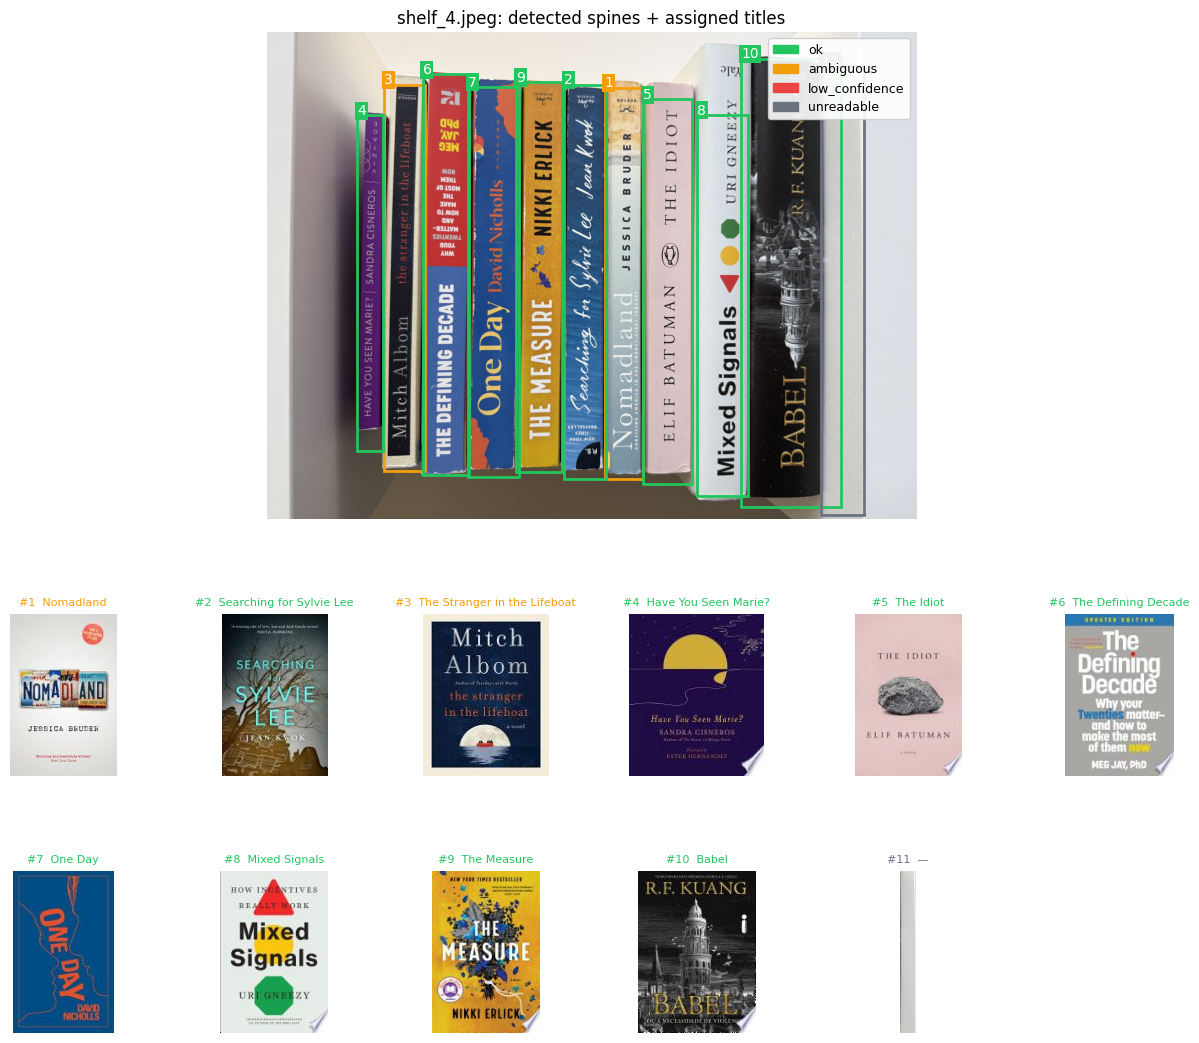


Summary for shelf_4.jpeg:
review_flag
ok            8
ambiguous     2
unreadable    1

Predicted titles:
  # 1  [ambiguous     ]  Nomadland                           -> Nomadland
  # 2  [ok            ]  Searching for Sylvie Lee            -> Searching for Sylvie Lee
  # 3  [ambiguous     ]  the stranger in the lifeboat        -> The Stranger in the Lifeboat
  # 4  [ok            ]  Have You Seen Marie?                -> Have You Seen Marie?
  # 5  [ok            ]  The Idiot                           -> The Idiot
  # 6  [ok            ]  The Defining Decade: How to Make the Most of the Next Decade -> The Defining Decade
  # 7  [ok            ]  One Day                             -> One Day
  # 8  [ok            ]  Mixed Signals                       -> Mixed Signals
  # 9  [ok            ]  The Measure                         -> The Measure
  #10  [ok            ]  Babel                               -> Babel
  #11  [unreadable    ]  (no ocr)                            -> (no match)

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

SAMPLE_SHELF = MY_BOOKS_DIR / "shelf_4.jpeg"  # change to inspect another shelf

FLAG_COLORS = {"ok": "#22c55e", "ambiguous": "#f59e0b",
               "low_confidence": "#ef4444", "unreadable": "#6b7280"}

sample_df = catalog_shelf(SAMPLE_SHELF, save=False, verbose=False, progress=False)
sample_img = Image.open(SAMPLE_SHELF).convert("RGB")

n_spines = len(sample_df)
n_cols = min(6, n_spines)
n_rows = (n_spines + n_cols - 1) // n_cols

fig = plt.figure(figsize=(16, 9 + 2 * n_rows))
gs = GridSpec(1 + n_rows, n_cols, figure=fig, height_ratios=[3] + [1] * n_rows,
              hspace=0.35, wspace=0.15)

# Top: shelf with bounding boxes
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(sample_img)
ax_main.set_title(f"{SAMPLE_SHELF.name}: detected spines + assigned titles", fontsize=12)
ax_main.axis("off")

for _, row in sample_df.iterrows():
    x1, y1, x2, y2 = row["bbox"]
    color = FLAG_COLORS.get(row["review_flag"], "#888")
    ax_main.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=color, facecolor="none"))
    label = f'{row["spine_idx"] + 1}'
    ax_main.text(x1, max(y1 - 6, 8), label, color="white", fontsize=10,
                 bbox=dict(facecolor=color, edgecolor="none", pad=1.5))

# Legend for review flags
handles = [patches.Patch(color=c, label=k) for k, c in FLAG_COLORS.items()]
ax_main.legend(handles=handles, loc="upper right", framealpha=0.9, fontsize=9)

# Bottom: matched cover thumbnails (or spine crop if no match)
for i, (_, row) in enumerate(sample_df.iterrows()):
    r, c = divmod(i, n_cols)
    ax = fig.add_subplot(gs[1 + r, c])
    thumb_url = row.get("match_thumbnail", "")
    img = _download_thumbnail(thumb_url) if thumb_url else None
    if img is None:
        x1, y1, x2, y2 = row["bbox"]
        img = sample_img.crop((int(x1), int(y1), int(x2), int(y2)))
    ax.imshow(img)
    ax.axis("off")
    title = (row["match_title"] or row["ocr_title"] or "—")[:30]
    flag_color = FLAG_COLORS.get(row["review_flag"], "#888")
    ax.set_title(f'#{row["spine_idx"] + 1}  {title}', fontsize=8, color=flag_color)

plt.tight_layout()
plt.show()

print(f"\nSummary for {SAMPLE_SHELF.name}:")
print(sample_df["review_flag"].value_counts().to_string())
print("\nPredicted titles:")
for _, r in sample_df.iterrows():
    print(f"  #{r['spine_idx']+1:>2d}  [{r['review_flag']:<14s}]  "
          f"{r['ocr_title'] or '(no ocr)':<35s} -> {r['match_title'] or '(no match)'}")

## 7) Frontend — Gradio app

Minimal UI: upload a shelf photo → see the annotated image + a grid of matched books (thumbnail, title, author, review flag). `ok` entries rendered normally; `ambiguous` / `low_confidence` get a warning badge; `unreadable` go to a separate 'Needs review' row.

Run the cell and click the local URL it prints. Requires `gradio` (add to `requirements.txt`).


In [ ]:
FLAG_BADGE = {
    "ok":              "🟢 ok",
    "ambiguous":       "🟡 ambiguous",
    "low_confidence":  "🟠 low confidence",
    "unreadable":      "🔴 unreadable",
}

def render_catalog_html(df: pd.DataFrame) -> str:
    def card(row):
        thumb = row["match_thumbnail"] or ""
        img = f'<img src="{thumb}" style="width:90px;height:auto;border-radius:4px;"/>' if thumb else \
              '<div style="width:90px;height:130px;background:#eee;border-radius:4px;display:flex;align-items:center;justify-content:center;color:#999;font-size:11px;">no cover</div>'
        title = row["match_title"] or row["ocr_title"] or "(unknown)"
        authors = ", ".join(row["match_authors"]) if isinstance(row["match_authors"], list) else row["match_authors"]
        badge = FLAG_BADGE.get(row["review_flag"], row["review_flag"])
        sim = row["clip_sim"]
        return (
            '<div style="display:flex;gap:10px;padding:8px;border:1px solid #e5e5e5;border-radius:8px;margin:6px;width:320px;">'
            f"{img}"
            '<div style="font-size:13px;line-height:1.3;">'
            f'<div style="font-weight:600;">{title}</div>'
            f'<div style="color:#555;">{authors or ""}</div>'
            f'<div style="margin-top:4px;color:#777;font-size:11px;">{badge} · sim={sim:.2f}</div>'
            "</div></div>"
        )
    confident = df[df["review_flag"].isin(["ok", "ambiguous"])]
    review    = df[df["review_flag"].isin(["low_confidence", "unreadable"])]
    html  = f'<h3>Catalog ({len(confident)} confident, {len(review)} need review)</h3>'
    html += '<div style="display:flex;flex-wrap:wrap;">' + "".join(card(r) for _, r in confident.iterrows()) + "</div>"
    if len(review):
        html += '<h3 style="margin-top:16px;">Needs review</h3>'
        html += '<div style="display:flex;flex-wrap:wrap;">' + "".join(card(r) for _, r in review.iterrows()) + "</div>"
    return html

def launch_app():
    import gradio as gr
    def process(img):
        if img is None:
            return "<p>Upload a shelf photo.</p>", None
        tmp = CATALOG_DIR / "_upload.jpg"
        Image.fromarray(img).save(tmp)
        df = catalog_shelf(tmp, save=False)
        return render_catalog_html(df), df
    with gr.Blocks(title="Bookshelf Catalog") as demo:
        gr.Markdown("# 📚 Bookshelf → Catalog\nUpload a photo of a bookshelf; get a structured catalog back.")
        with gr.Row():
            inp = gr.Image(type="numpy", label="Shelf photo")
            out_df = gr.Dataframe(label="Raw catalog (debug)", wrap=True)
        out_html = gr.HTML()
        btn = gr.Button("Catalog this shelf", variant="primary")
        btn.click(process, inputs=inp, outputs=[out_html, out_df])
    demo.launch(share=False, inbrowser=False)

# launch_app()   # uncomment to run